dataset- https://www.kaggle.com/datasets/vishakhdapat/customer-segmentation-clustering

In [49]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [50]:
df = pd.read_csv('cust_seg.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


- Id: Unique identifier for each individual in the dataset.
- Year_Birth: The birth year of the individual.
- Education: The highest level of education attained by the individual.
- Marital_Status: The marital status of the individual.
- Income: The annual income of the individual.
- Kidhome: The number of young children in the household.
- Teenhome: The number of teenagers in the household.
- Dt_Customer: The date when the customer was first enrolled or became a part of the company's database.
- Recency: The number of days since the last purchase or interaction.
- MntWines: The amount spent on wines.
- MntFruits: The amount spent on fruits.
- MntMeatProducts: The amount spent on meat products.
- MntFishProducts: The amount spent on fish products.
- MntSweetProducts: The amount spent on sweet products.
- MntGoldProds: The amount spent on gold products.
- NumDealsPurchases: The number of purchases made with a discount or as part of a deal.
- NumWebPurchases: The number of purchases made through the company's website.
- NumCatalogPurchases: The number of purchases made through catalogs.
- NumStorePurchases: The number of purchases made in physical stores.
- NumWebVisitsMonth: The number of visits to the company's website in a month.
- AcceptedCmp3: Binary indicator (1 or 0) whether the individual accepted the third marketing campaign.
- AcceptedCmp4: Binary indicator (1 or 0) whether the individual accepted the fourth marketing campaign.
- AcceptedCmp5: Binary indicator (1 or 0) whether the individual accepted the fifth marketing campaign.
- AcceptedCmp1: Binary indicator (1 or 0) whether the individual accepted the first marketing campaign.
- AcceptedCmp2: Binary indicator (1 or 0) whether the individual accepted the second marketing campaign.
- Complain: Binary indicator (1 or 0) whether the individual has made a complaint.
- Z_CostContact: A constant cost associated with contacting a customer.
- Z_Revenue: A constant revenue associated with a successful campaign response.
- Response: Binary indicator (1 or 0) whether the individual responded to the marketing campaign.

In [51]:
df.shape

(2240, 29)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [53]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [54]:
# 24 null values in income, its round 1%. very less, so we can drop that data.
df.dropna(inplace = True)
df.isna().sum().sum()

np.int64(0)

In [55]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [56]:
# Education, Marital_Status, Dt_Customer are categorical columns.

df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [57]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [58]:
df["Marital_Status"] = df["Marital_Status"].replace({
    "Alone": "Single"
})
df = df[~df["Marital_Status"].isin(["Absurd", "YOLO"])]
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      474
Divorced    232
Widow        76
Name: count, dtype: int64

In [59]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

In [60]:
df["Age"] = 2026 - df["Year_Birth"]

In [61]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,42
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,45


In [62]:
df["Children"] = df["Kidhome"]+df["Teenhome"]

In [63]:
df.drop(columns = ['Year_Birth', 'Kidhome', 'Teenhome'], inplace=True)

In [64]:
df.columns

Index(['ID', 'Education', 'Marital_Status', 'Income', 'Dt_Customer', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact',
       'Z_Revenue', 'Response', 'Age', 'Children'],
      dtype='object')

In [65]:
spending = [ 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts','MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spending].sum(axis=1)

In [66]:
df[['Total_Spending']]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [67]:
df['Customer_Since'] = (pd.Timestamp("today") - df['Dt_Customer']).dt.days

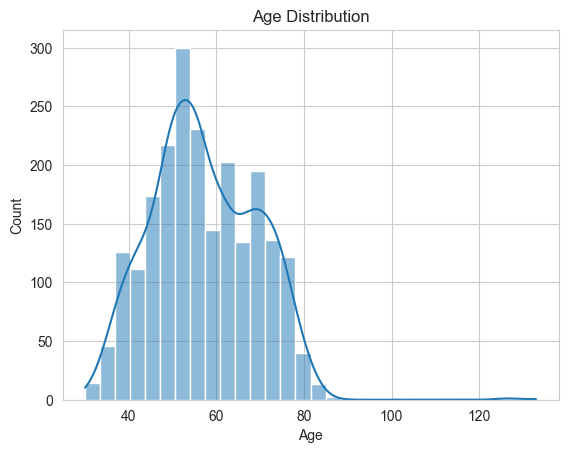

In [68]:
sns.histplot(df['Age'], kde = True, bins=30)
plt.title("Age Distribution")
plt.show()

most of the customers are in the age of 40-60

In [69]:
df['Age'].min()

np.int64(30)

In [70]:
df['Age'].max()

np.int64(133)

In [71]:
df['Age'].mean()

np.float64(57.18896925858951)

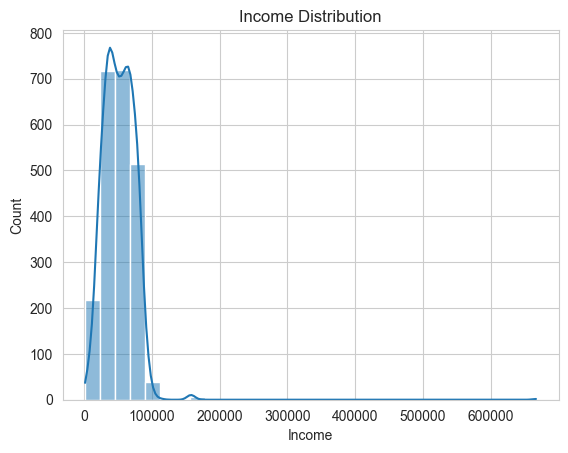

In [72]:
sns.histplot(df['Income'], kde=True, bins =30)
plt.title("Income Distribution")
plt.show()

most of the customers have an income below 100000

In [73]:
df['Income'].min()

np.float64(1730.0)

In [74]:
df['Income'].max()

np.float64(666666.0)

In [75]:
df['Income'].mean()

np.float64(52232.51084990959)

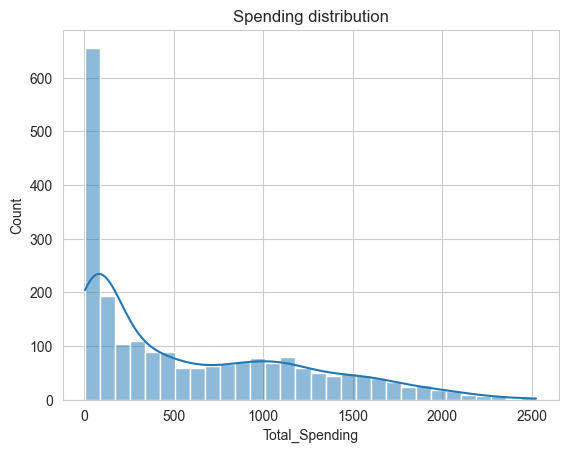

In [76]:
sns.histplot(df['Total_Spending'], kde=True, bins = 30)
plt.title("Spending distribution")
plt.show()

most of the spendings are in the range of 0 to 1000. 

In [77]:
df['Total_Spending'].min()

np.int64(5)

In [78]:
df['Total_Spending'].max()

np.int64(2525)

In [79]:
df['Total_Spending'].mean()

np.float64(606.7115732368896)

<Axes: xlabel='Education', ylabel='Income'>

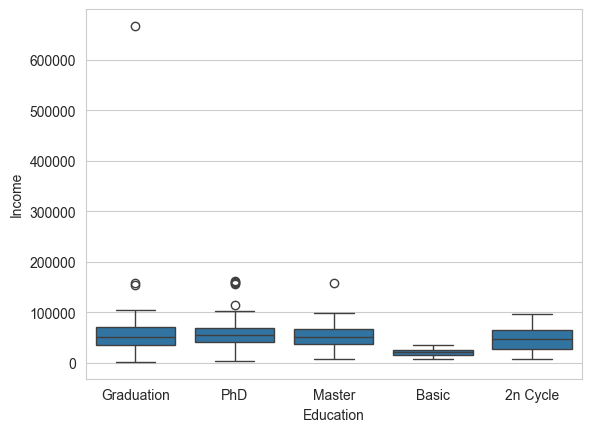

In [80]:
sns.set_style('whitegrid')
sns.boxplot(x = 'Education', y = 'Income', data = df)

- highest income- phd , but the starting income is highest in the case of Master Education customers.
- lowest income- basic education 

<Axes: xlabel='Marital_Status', ylabel='Total_Spending'>

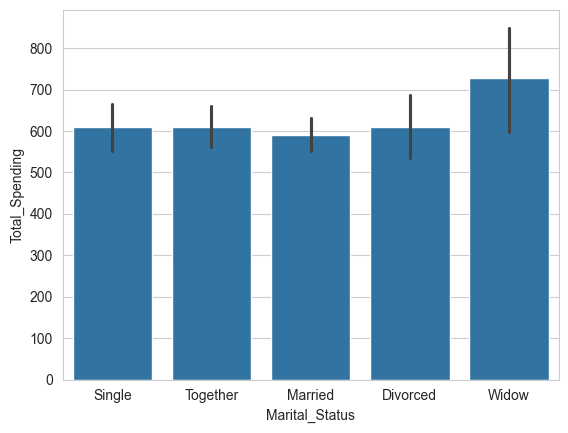

In [81]:
sns.barplot(x = 'Marital_Status', y = 'Total_Spending', data = df)

- the spending is highest in the case of widow category. This may be because the number of widows are very less in the dataset as compared to other categories, so a very few high spending people may influence the avg. Also, widows are generally older, having children, so they spend more. They may be more financially stable as compared to others.
- the spending for other categories is almost equal, with that of Married category being a bit lower, this may  be due to spending split between 2 people.

<Axes: xlabel='Marital_Status', ylabel='Total_Spending'>

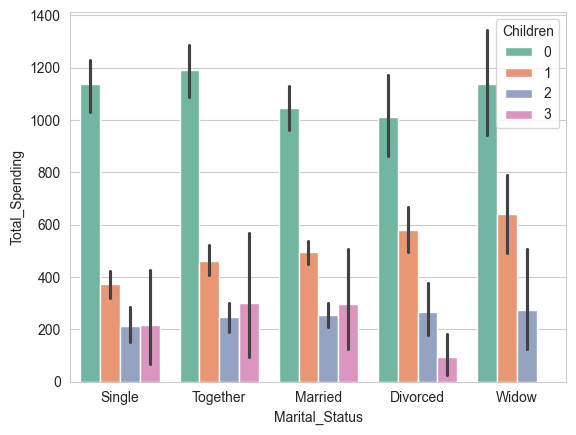

In [82]:
sns.barplot(x = 'Marital_Status', y = 'Total_Spending', hue = 'Children', data = df, palette='Set2')

as the no. of children increases, spending decreases.

In [83]:
df.groupby('Education')['Total_Spending'].mean().sort_values(ascending=False)

Education
PhD           677.789144
Graduation    621.153363
Master        608.230769
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

- the spending is maximum in the case of PhD grads, followed by Graduation, master, 2n cycle and lowest for people with basic education.

<Axes: xlabel='Education', ylabel='Total_Spending'>

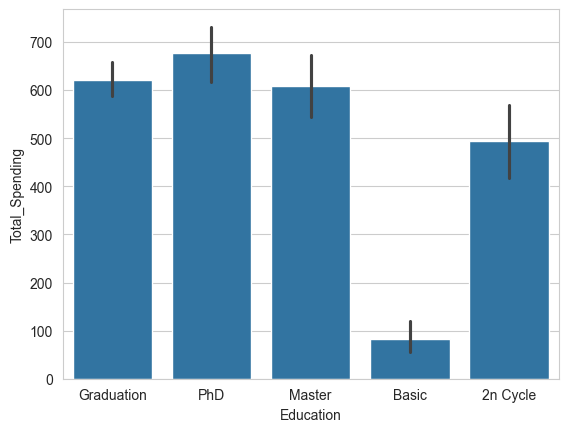

In [84]:
sns.barplot(x = 'Education', y = 'Total_Spending', data = df)

In [85]:
df['AcceptedAny'] = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis = 1)

In [86]:
df.drop(columns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5'], axis = 1, inplace = True)

In [87]:
df['AcceptedAny'].unique()

array([0, 1, 2, 3, 4])

In [88]:
df['AcceptedAny'] = df['AcceptedAny'].apply(lambda x: 1 if x>0 else 0)

In [89]:
bins = [18, 30, 40, 50, 60, 70, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['AgeGrp'] = pd.cut(df['Age'], bins = bins, labels = labels)

C:\Users\Mrunmayee Potdar\AppData\Local\Temp\ipykernel_14432\4151880130.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_grp = df.groupby('AgeGrp')['Income'].mean()


<Axes: xlabel='Income', ylabel='AgeGrp'>

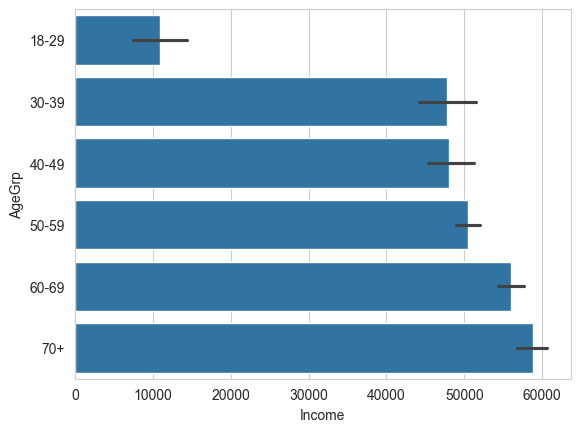

In [90]:
age_grp = df.groupby('AgeGrp')['Income'].mean()
sns.barplot(x = 'Income', y = 'AgeGrp', data = df)

as age inc, income inc

<Axes: >

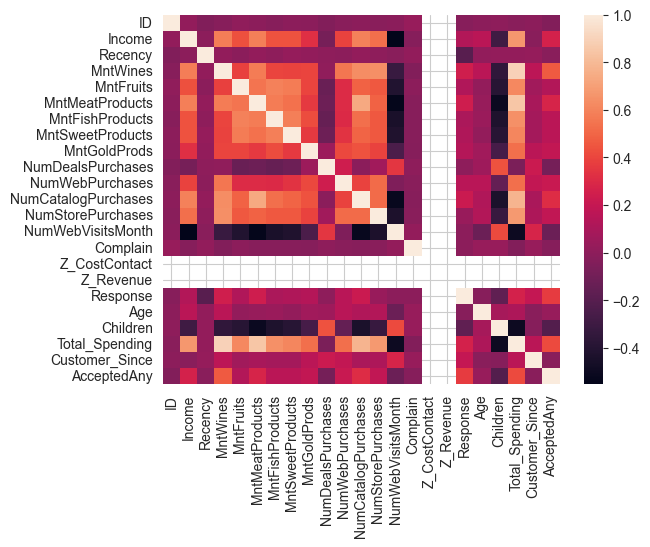

In [91]:
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=False, fmt='.2f')

In [92]:
df.columns

Index(['ID', 'Education', 'Marital_Status', 'Income', 'Dt_Customer', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Z_CostContact', 'Z_Revenue',
       'Response', 'Age', 'Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGrp'],
      dtype='object')

In [94]:
features = [
    "Age",
    "Income",
    "Total_Spending",
    "NumWebPurchases",
    "NumStorePurchases",
    "Recency", 
    "Children"   
]

X = df[features]

In [95]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [96]:
from sklearn.cluster import KMeans

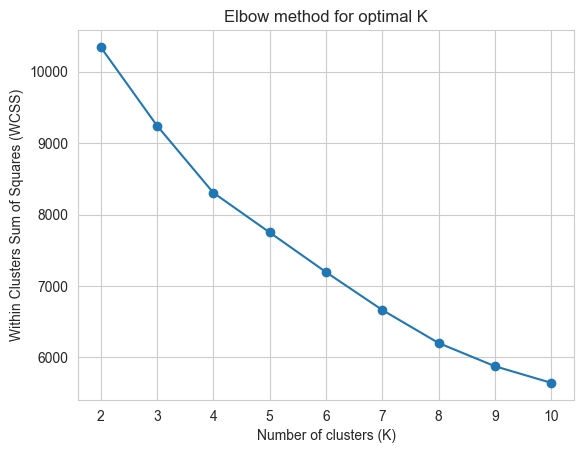

In [105]:
wcss = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(k_range, wcss, marker = 'o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Within Clusters Sum of Squares (WCSS)")
plt.title("Elbow method for optimal K")
plt.show()

elbow bends at 4 so we take k=4.

checking by silhoutte score.

In [106]:
from sklearn.metrics import silhouette_score

best_k = 0
best_score = -1

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    
    if score > best_score:
        best_score = score
        best_k = k

print("Best k:", best_k)

Best k: 2


2 clusters are too broad for useful insights.

The Silhouette Score was highest for k=2, indicating strong separation into two broad groups. However, the Elbow Method showed a clear bend at k=4. Since customer segmentation benefits from more detailed groupings, k=4 was selected as the optimal number of clusters.

In [107]:
k_means_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = k_means_final.fit_predict(X_scaled)
df.head()

,ID,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Z_CostContact,Z_Revenue,Response,Age,Children,Total_Spending,Customer_Since,AcceptedAny,AgeGrp,cluster
0,5524,Graduation,Single,58138.0,2012-09-04,58,635,88,546,172,...,3,11,1,69,0,1617,4935,0,60-69,1
1,2174,Graduation,Single,46344.0,2014-03-08,38,11,1,6,2,...,3,11,0,72,2,27,4385,0,70+,3
2,4141,Graduation,Together,71613.0,2013-08-21,26,426,49,127,111,...,3,11,0,61,0,776,4584,0,60-69,2
3,6182,Graduation,Together,26646.0,2014-02-10,26,11,4,20,10,...,3,11,0,42,1,53,4411,0,40-49,0
4,5324,PhD,Married,58293.0,2014-01-19,94,173,43,118,46,...,3,11,0,45,1,422,4433,0,40-49,0


In [108]:
cluster_summary = df.groupby('cluster')[features].mean()

In [109]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,Recency,Children
cluster,,,,,,,
0,49.336940,30867.979907,109.219474,2.194745,3.219474,49.261206,0.812983
1,56.777542,79273.074153,1430.777542,4.574153,8.277542,50.563559,0.059322
2,61.470958,61106.929356,835.912088,6.861852,8.189953,47.858713,1.043956
3,62.774123,42159.486842,139.425439,2.372807,3.559211,48.850877,1.925439


In [111]:
df['cluster'].value_counts()

cluster
0    647
2    637
1    472
3    456
Name: count, dtype: int64

In [115]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:,0], pca_data[:,1]

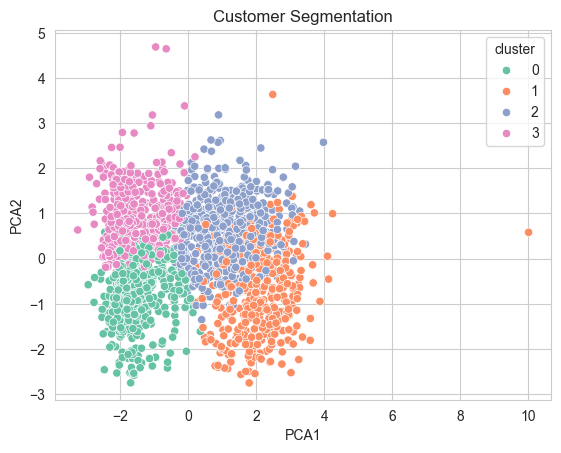

In [116]:
sns.scatterplot(x = 'PCA1', y = 'PCA2', data=df, hue='cluster', palette='Set2')
plt.title('Customer Segmentation')
plt.show()

In [119]:
X.columns

Index(['Age', 'Income', 'Total_Spending', 'NumWebPurchases',
       'NumStorePurchases', 'Recency', 'Children'],
      dtype='object')

In [123]:
cluster_profile = df.groupby('cluster')[['Age', 'Income', 'Total_Spending', 'NumWebPurchases','NumStorePurchases', 'Recency', 'Children']].mean()
print(cluster_profile)

               Age        Income  Total_Spending  NumWebPurchases  \
cluster                                                             
0        49.336940  30867.979907      109.219474         2.194745   
1        56.777542  79273.074153     1430.777542         4.574153   
2        61.470958  61106.929356      835.912088         6.861852   
3        62.774123  42159.486842      139.425439         2.372807   

         NumStorePurchases    Recency  Children  
cluster                                          
0                 3.219474  49.261206  0.812983  
1                 8.277542  50.563559  0.059322  
2                 8.189953  47.858713  1.043956  
3                 3.559211  48.850877  1.925439  


- Cluster 0 --> Younger Budget Shoppers. 
- Cluster 1 --> High Value Elites.
- Cluster 2 --> Established Digital Shoppers.
- Cluster 3 --> Family Focussed Seniors.

In [124]:
cluster_names = {
    0: 'Budget Starters',
    1: 'High-Value Elites',
    2: 'Established Digital Shoppers',
    3: 'Family-Focused Seniors'
}

df['Cluster_Name'] = df['cluster'].map(cluster_names)

print(df[['cluster', 'Cluster_Name']].head())

   cluster                  Cluster_Name
0        1             High-Value Elites
1        3        Family-Focused Seniors
2        2  Established Digital Shoppers
3        0               Budget Starters
4        0               Budget Starters


In [125]:
import joblib 
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(sc, 'scaler.pkl')

['scaler.pkl']

In [127]:
X.describe()

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,Recency,Children
count,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000
mean,57.188969,52232.510850,606.711573,4.083183,5.800181,49.050633,0.948011
std,11.982065,25187.455359,603.163013,2.741930,3.253616,28.940794,0.749196
min,30.000000,1730.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,49.000000,35233.500000,68.750000,2.000000,3.000000,24.000000,0.000000
50%,56.000000,51381.500000,396.000000,4.000000,5.000000,49.000000,1.000000
75%,67.000000,68522.000000,1047.250000,6.000000,8.000000,74.000000,1.000000
max,133.000000,666666.000000,2525.000000,27.000000,13.000000,99.000000,3.000000
